# 第25课 · 蒙眼下山，沿负梯度走到谷底——梯度下降（gradient descent，GD）与权重更新公式

**目标**：要让函数变小，就朝梯度的**反方向**走一小步，反复迭代。

`新位置 = 旧位置 − 学习率（learning rate，lr） × 梯度`

**为什么对 Aurora 重要**：`aurora.train` 里每次调用 `optimizer.step()`，执行的就是这一行更新规则；学习率设错，收敛曲线（convergence curve）就会在极值点两侧震荡或长期停滞。

← **上一课**　[L24 · 链式法则](L24_chain_rule.ipynb)

> 上节课学习了 **链式法则**：函数套函数的求导，反向传播的数学基础。  
> 本课将探讨 **梯度下降**。

## 本课剧情：蒙眼下山

你被蒙上眼睛，站在山坡某处，目标是走到山谷。

你能做的：用脚探测当前位置的坡度（=梯度），然后沿最陡下坡方向（=负梯度）走一步。重复这个过程，你就会越来越接近谷底。

这就是**梯度下降**（gradient descent）：

```
x ← x - lr · ∇f(x)
```

- `x`：当前位置（权重向量）
- `∇f(x)`：当前坡度（梯度）
- `lr`：步长（学习率，learning rate）

三个核心问题：
1. **为什么是"负"梯度？** 梯度指向上坡，走反方向才是下坡。
2. **lr 太大会怎样？** 步子太大，可能跨过谷底反弹到另一侧（震荡/发散）。
3. **何时停下？** 梯度接近零时（∇f(x) ≈ 0）——**但此时可能是以下几种地点之一**：
   - **谷底（局部最小值）**：周围任何方向走都是上坡。这是理想的停止点。
   - **鞍点（saddle point）**：某些方向上升、某些方向下降（像山脉的鞍部）。梯度为零，但不是最小值。
   - **高原（plateau）**：梯度很小但不完全为零，函数值变化缓慢。
   
   在深度学习中，**高维空间的梯度下降更可能卡在鞍点而非局部最小值**——这是后续 L58 用动量（momentum）等高级优化算法的原因。本课不用担心，f(x)=(x−3)² 这样的简单二次函数没有鞍点。

本课实现一步更新 `gd_step(x, grad_value, lr)` 并验证：  
50步后 f(x)=(x-3)² 从 x=0 收敛到 x≈3。

## 1. 手算一步：f(x) = (x−3)²

**解析梯度**：f'(x) = 2(x−3)

**出发点**：x₀ = 0，学习率 lr = 0.1

**第一步更新**：
```
x₁ = x₀ - lr · f'(x₀)
   = 0 - 0.1 · f'(0)
   = 0 - 0.1 · 2·(0-3)
   = 0 - 0.1 · (-6)
   = 0.6
```

**第二步**：
```
x₂ = x₁ - 0.1 · f'(x₁)
   = 0.6 - 0.1 · 2·(0.6-3)
   = 0.6 - 0.1 · (-4.8)
   = 1.08
```

每步后 x 更接近极小值点 x*=3，步长按公比 `(1 - 2·lr)` = 0.8 几何收缩。

---

### 🔬 为什么误差每步乘以 (1 - 2·lr)？详细推导

这不是魔法——让我们直接推导这个公比是怎么来的。

**定义误差** e_k = x_k - 3（当前位置与最优解 3 的距离）

**一步迭代的数学**：
```
x_{k+1} = x_k - lr · f'(x_k)
        = x_k - lr · 2(x_k - 3)                  【代入 f'(x)=2(x-3)】
        = x_k - 2·lr·x_k + 2·lr·3
        = x_k(1 - 2·lr) + 6·lr
```

**用误差改写**。注意 x_k = e_k + 3（误差加上最优解），代入上式：
```
x_{k+1} = (e_k + 3)(1 - 2·lr) + 6·lr
        = e_k(1 - 2·lr) + 3(1 - 2·lr) + 6·lr
        = e_k(1 - 2·lr) + 3 - 6·lr + 6·lr
        = e_k(1 - 2·lr) + 3
```

所以：
```
e_{k+1} = x_{k+1} - 3 = (1 - 2·lr)·e_k
```

**这说明什么？**
- 每一步，误差都乘以同一个数 (1 - 2·lr)（称为**公比**）
- 如果 |公比| < 1，误差指数衰减 → 收敛到 0（即 x → 3）
- 如果 |公比| ≥ 1，误差不收缩，序列不能逼近最优解

**对 f(x)=(x-3)²，lr=0.1 的例子验证**：
- 公比 = 1 - 2×0.1 = 0.8
- e_0 = 0 - 3 = -3
- e_1 = 0.8 × (-3) = -2.4，所以 x_1 = -2.4 + 3 = 0.6 ✓
- e_2 = 0.8 × (-2.4) = -1.92，所以 x_2 = -1.92 + 3 = 1.08 ✓

---

**lr 的边界条件**（对本例 f'(x)=2(x−3)，根据公比判断收敛）：
- **0 < lr < 1**：|1 − 2·lr| < 1 → 公比在 (−1, 1) 之间 → 收敛（误差每步按 |公比| 倍缩小）
- **lr = 0.5**：1 − 2·0.5 = 0 → 公比为 0 → e_1 = 0，**一步到达最优解**（x₁ = 3）
- **lr = 1**：1 − 2·1 = −1 → 公比 −1 → e_k 符号交替，x 在 0 和 6 之间**永久震荡**，永远到不了 3
- **lr > 1**：|1 − 2·lr| > 1 → 公比幅度 > 1 → 误差放大 → **发散**

💡 **为什么这个规则对其他函数可能不同？** 这套分析基于 f'(x)=2(x−3) 这个特定的导数形式。对于其他函数，导数的系数（比如"2"）会改变，公比的表达式也会变。**所以「0<lr<1 就收敛」不能无脑套用到一切函数**——必须针对具体的 f'(x)（本例二次、二阶导为 2）推导相应的 lr 边界。

## 实验入口：用数值变化观察函数

三个关键变量：`x`（当前位置）、`grad`（该点梯度值）、`lr`（学习率）。观察每轮迭代后 `x` 怎样靠近 3，以及 `f(x)` 怎样收敛到 0。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
grad = lambda x: 2*(x-3)      # f'(x)
x = 0.0; lr = 0.1
for step in range(30):
    x = x - lr * grad(x)
print('收敛到 x =', round(x, 4), ' (最小值在 x=3)')

收敛到 x = 2.9963  (最小值在 x=3)


## 动手观察：变化率不是一句口号

先在单个点上算梯度和一步更新，确认数值正确，再进入多步迭代。

### 📐 数值微分：用有限差分近似导数

导数的数学定义是极限：
$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

但计算机无法真正取极限，只能用一个**很小的 h**（比如 1e-3）来模拟。这就是**数值微分**。

有几种选择：
- **左差分**：$\frac{f(x) - f(x-h)}{h}$（向回看）
- **右差分**：$\frac{f(x+h) - f(x)}{h}$（向前看）
- **中心差分**：$\frac{f(x+h) - f(x-h)}{2h}$（前后都看）

**为什么选中心差分？** 因为它对称地在 x 的两侧测量变化，精度比单侧差分高一个数量级。用泰勒展开可以证明：中心差分的误差是 O(h²)，而左/右差分的误差是 O(h)。

**浮点数精度会损失吗？** 确实会。h 太小（比如 1e-15）会导致 f(x+h) 和 f(x-h) 几乎相同，两者差值中高位数字丧失（消去误差）。所以 h 需要折中——通常选 1e-4 到 1e-5，既能逼近导数，又避免浮点精度丧失。

In [3]:
import numpy as np

def f(x):
    return x**2

xs = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
h = 1e-3
slopes = (f(xs + h) - f(xs - h)) / (2 * h)

print('x =', xs)
print('f(x) =', f(xs))
print('近似斜率 =', np.round(slopes, 3))
print('理论斜率 2x =', 2 * xs)


x = [-2. -1.  0.  1.  2.]
f(x) = [4. 1. 0. 1. 4.]
近似斜率 = [-4. -2.  0.  2.  4.]
理论斜率 2x = [-4. -2.  0.  2.  4.]


## 代码实验：遍历不同位置，看斜率如何变化

把 `x` 从 −3 遍历到 3，直接打印每个点的函数值和斜率，看清楚梯度在极值点两侧的符号变化。

In [4]:
import numpy as np

def f(x):
    return x**2 + 2*x

h = 1e-4
for x in np.linspace(-3, 3, 7):
    slope = (f(x + h) - f(x - h)) / (2*h)
    print(f'x={x:5.2f} | f(x)={f(x):6.2f} | slope≈{slope:6.2f}')


x=-3.00 | f(x)=  3.00 | slope≈ -4.00
x=-2.00 | f(x)=  0.00 | slope≈ -2.00
x=-1.00 | f(x)= -1.00 | slope≈  0.00
x= 0.00 | f(x)=  0.00 | slope≈  2.00
x= 1.00 | f(x)=  3.00 | slope≈  4.00
x= 2.00 | f(x)=  8.00 | slope≈  6.00
x= 3.00 | f(x)= 15.00 | slope≈  8.00


## 2. ✏️ 实现一步更新 `gd_step(x, grad_value, lr)`

**推理路线**：
1. `grad_value` 指向函数上升最快的方向；要让函数值下降，就从当前位置减去它：`x - something`。
2. 步长由 `lr` 控制：实际移动量是 `lr * grad_value`，而不是直接减去整个梯度（梯度数值可能很大）。
3. 合并得到：`x_new = x - lr * grad_value`，整个函数只需一行，不需要循环。

**参考输入输出**：`f(x)=(x−3)²`，当前 `x=0`，梯度 `2(0−3)=−6`，`lr=0.1` → 新 `x = 0 − 0.1×(−6) = 0.6`（向 3 靠近）。

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### 写代码前，先把变量表补完整

写 `gd_step` 前明确三件事：
- 输入：`x`（当前位置，float）、`grad_value`（该点梯度值）、`lr`（学习率，控制步长大小）
- 关键步骤：将移动量（`lr` 乘以梯度方向）从当前位置**减去**，得到新位置
- 返回：执行一步梯度下降后的新位置


In [5]:
def gd_step(x, grad_value, lr):
    # ✏️ TODO: 返回更新后的 x
    raise NotImplementedError("请实现 gd_step：返回 x 减去 lr 乘以梯度的新位置")


In [6]:
# 单步验证 — 先实现 gd_step 再运行此格
# 预期：gd_step(0.0, -6.0, 0.1) = 0.0 - 0.1*(-6.0) = 0.6
try:
    result = gd_step(0.0, -6.0, 0.1)
    assert abs(result - 0.6) < 1e-9, f"单步验证失败：期望 0.6，得到 {result}"
    print('✅ 单步验证通过：gd_step(0.0, -6.0, 0.1) =', result)
except (NotImplementedError, TypeError) as e:
    print('⚠️', e)


⚠️ 请实现 gd_step：返回 x 减去 lr 乘以梯度的新位置


In [7]:
try:
    x = 0.0; lr = 0.1
    for _ in range(50):
        x = gd_step(x, 2*(x-3), lr)
    assert abs(x - 3.0) < 1e-3
    print('✅ 通过：你实现了梯度下降的一步，迭代后 x =', round(x, 4))
except (NotImplementedError, TypeError) as e:
    print('⚠️', e)


⚠️ 请实现 gd_step：返回 x 减去 lr 乘以梯度的新位置


## 3. 实战预告：用梯度下降拟合一条直线 y = 2x + 1（带噪声）

（这一格直接运行看效果，是 Month 2 线性回归（linear regression）的雏形）

### 从一维到多维：线性回归中的梯度下降

想象我们要从数据学会一条直线 y = w·x + b。

**问题设置**：
- 数据点：(X_i, y_i)，i = 1, 2, ..., n
- 模型预测：ŷ = w·X + b
- 误差：err_i = ŷ_i - y_i（预测值减真实值）
- **损失函数**（衡量所有误差）：MSE = (1/n) Σ(err_i)²

这里 w 和 b 是我们要优化的参数，像一维情况的"位置 x"。

**求 w 的偏导数** ∂(MSE)/∂w：

应用链式法则：
```
∂(MSE)/∂w = ∂/∂w [ (1/n) Σ(err_i)² ]
          = (1/n) Σ 2·err_i · ∂(err_i)/∂w
          = (1/n) Σ 2·err_i · X_i                【因为 err_i = w·X_i + b - y_i，所以 ∂err_i/∂w = X_i】
          = 2 · (1/n) Σ err_i · X_i
```

**求 b 的偏导数** ∂(MSE)/∂b：
```
∂(MSE)/∂b = (1/n) Σ 2·err_i · ∂(err_i)/∂b
          = (1/n) Σ 2·err_i · 1                  【因为 ∂err_i/∂b = 1】
          = 2 · (1/n) Σ err_i
```

**梯度下降更新**（用 `np.mean(err * X)` 代替 `(1/n) Σ err_i·X_i`）：
```python
w -= lr * [∂(MSE)/∂w] = lr * 2 · mean(err * X)
b -= lr * [∂(MSE)/∂b] = lr * 2 · mean(err)
```

🔗 **和一维情况的对应**：f(x)=(x−3)² 时，梯度是 2(x−3)，所以 x 每次减 lr·2(x−3)。这里 err 就像"x−3"（偏离理想值的量），梯度也包含因子 2。完全一样的数学结构，只是现在有两个参数 (w, b) 而不是一个。

学到 w=2.03 (真值2), b=0.89 (真值1)


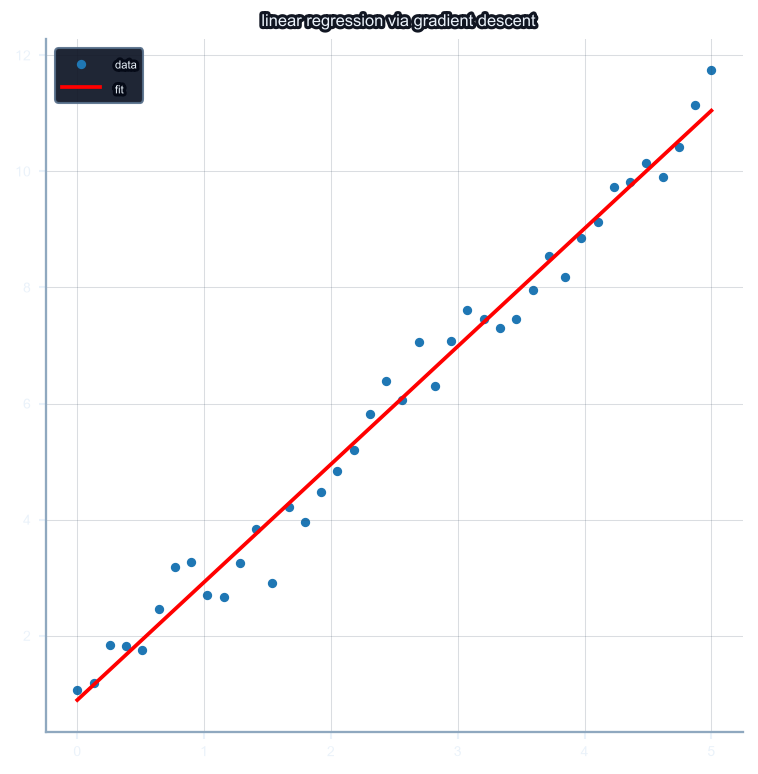

In [8]:
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)
X = np.linspace(0, 5, 40)
y = 2*X + 1 + rng.normal(0, 0.5, size=X.shape)   # 真实关系 + 噪声
w, b, lr = 0.0, 0.0, 0.01
for _ in range(2000):
    pred = w*X + b
    err = pred - y
    w -= lr * np.mean(err * X) * 2     # 对 MSE 的梯度
    b -= lr * np.mean(err) * 2
print(f'学到 w={w:.2f} (真值2), b={b:.2f} (真值1)')
plt.scatter(X, y, s=12, label='data')
plt.plot(X, w*X+b, 'r', label='fit')
plt.legend(); plt.title('linear regression via gradient descent'); plt.show()

**🔗 Aurora 连接**：本节实现的 `gd_step(x, grad_value, lr)` 封装了梯度下降的核心更新逻辑。当 Month 2 引入训练循环时，此更新规则将以 `optimizer.step()` 的形式出现，把「预测 → 算误差 → 沿梯度更新权重」这套逻辑推广到神经网络参数张量，支撑 ASR、音乐生成和 LLM 的全程训练。


## 参数实验：lr 大小决定收敛还是震荡

从 `x=-2.0` 出发，对 `f(x)=(x−3)²` 用 `lr=0.2` 跑 8 步，打印每步的 `x` 值：

- `lr=0.2`：步子适中，`x` 单调逼近极值点 3，8 步内可见明显收敛趋势。

改变 `lr` 观察不同行为：`lr=0.9` 步子较大，`x` 每步越过极值点 3 但振幅递减（在 0<lr<1 时仍收敛）；`lr=0.01` 步子很小，收敛稳定但需要更多步。亲眼看清学习率的大小对收敛行为的影响有多大。

In [9]:
def f(x):
    return (x - 3)**2

# 对比四种学习率的收敛行为
# lr<1 且 |1-2*lr|<1（即 0<lr<1）时收敛；lr=1.1 时 |1-2*1.1|=1.2>1，序列发散
for lr in [0.01, 0.2, 0.9, 1.1]:
    x = -2.0
    for step in range(8):
        grad = 2 * (x - 3)
        x = x - lr * grad
    fx = f(x)
    status = '✅ 收敛' if abs(x - 3) < 5 else '❌ 发散'
    print(f'lr={lr:.2f} | 8步后 x={x:9.3f} | f(x)={fx:10.2f} | {status}')


lr=0.01 | 8步后 x=   -1.254 | f(x)=     18.09 | ✅ 收敛
lr=0.20 | 8步后 x=    2.916 | f(x)=      0.01 | ✅ 收敛
lr=0.90 | 8步后 x=    2.161 | f(x)=      0.70 | ✅ 收敛
lr=1.10 | 8步后 x=  -18.499 | f(x)=    462.21 | ❌ 发散


## 🎯 未来的回报 (Future Payoff)

今天这行「沿负梯度走一步」的更新公式 `x ← x − lr · grad`，会在 **L56（反向传播）** 拿到每个权重的梯度后立刻用上，并在 **L58（训练循环）** 变成 `optimizer.step()`——神经网络训练的每一步，本质上就是今天这一步蒙眼下山。

## 本课收束

现在能调用 `gd_step(x, grad_value, lr)` 逐步更新 `x`，在 `f(x) = (x−3)²` 上验证收敛过程。这对应 Month 2 训练循环里每一步的参数更新。下一节（L26）将通过 cviz 等高线图展示梯度下降的收敛轨迹，直观对比不同学习率和起点下的收敛速度。

更往后在 L58 的训练循环里，这条更新公式会和 `Value` 的梯度传播合在一起，变成完整的参数更新一步。

✅ 观察：lr 过小→收敛慢；lr 过大→震荡或发散；最优 lr ≈ 0.1–0.5（取决于问题）


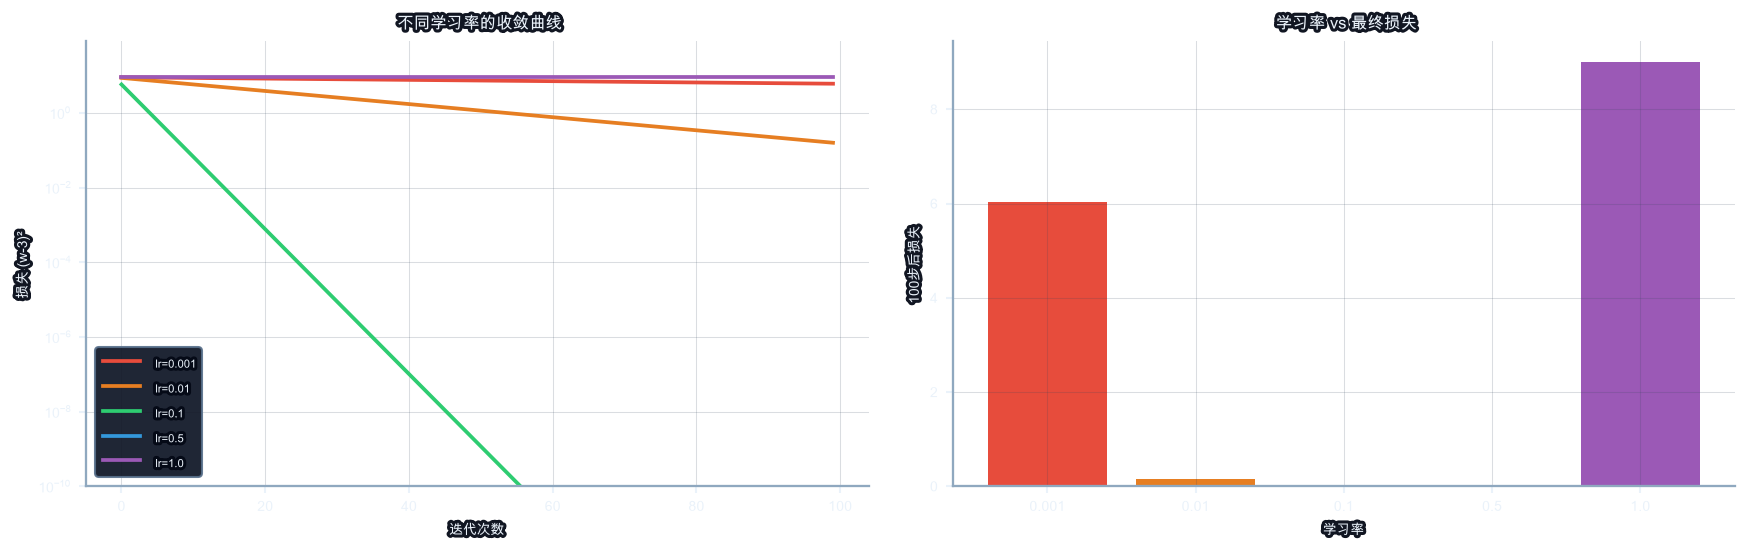

In [10]:
# ── 参数实验：学习率对收敛的影响 ─────────────────────────────────────────
import matplotlib.pyplot as plt

learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for lr, color in zip(learning_rates, colors):
    # 最小化 f(w) = (w - 3)^2，梯度 = 2*(w - 3)，最优解 w=3
    w, losses = 0.0, []
    for _ in range(100):
        grad = 2 * (w - 3.0)
        w -= lr * grad
        losses.append((w - 3.0) ** 2)
    axes[0].plot(losses, label=f'lr={lr}', color=color)

axes[0].set_xlabel('迭代次数'); axes[0].set_ylabel('损失 (w-3)²')
axes[0].set_title('不同学习率的收敛曲线'); axes[0].legend(); axes[0].set_yscale('log')
axes[0].set_ylim(bottom=1e-10)

# 100 步后各学习率的最终损失
final_losses = []
for lr in learning_rates:
    w = 0.0
    for _ in range(100):
        w -= lr * 2 * (w - 3.0)
    final_losses.append((w - 3.0) ** 2)

axes[1].bar([str(lr) for lr in learning_rates], final_losses, color=colors)
axes[1].set_xlabel('学习率'); axes[1].set_ylabel('100步后损失')
axes[1].set_title('学习率 vs 最终损失')
plt.tight_layout(); plt.show()

assert final_losses[2] < final_losses[0], "lr=0.1 应比 lr=0.001 收敛更快"
print("✅ 观察：lr 过小→收敛慢；lr 过大→震荡或发散；最优 lr ≈ 0.1–0.5（取决于问题）")

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


---

## 🌐 梯度在多维中的含义

**一维回顾**：f(x) = (x−3)²，导数 f'(x) = 2(x−3) 是一个标量，表示函数沿 x 轴方向的变化率。

**二维情况**：f(x, y) = x² + y²。现在有两个方向，我们需要两个数字来描述"坡度"。

**偏导数**（partial derivative）：对一个变量求导，其他变量当作常数
- ∂f/∂x = 2x（f 沿 x 方向的变化率）
- ∂f/∂y = 2y（f 沿 y 方向的变化率）

**梯度向量** ∇f（nabla）：把所有偏导数排成一个向量
$$\nabla f(x, y) = \begin{bmatrix} \partial f/\partial x \\ \partial f/\partial y \end{bmatrix} = \begin{bmatrix} 2x \\ 2y \end{bmatrix}$$

在点 (x, y) = (2, 4) 处，梯度是 ∇f(2,4) = [4, 8]——这个向量指向函数增长最快的方向。

**梯度下降怎么走一步**？沿梯度的**反方向**，即 (x, y) 的每个分量都按对应的梯度分量减少：
$$\begin{bmatrix} x_{\text{new}} \\ y_{\text{new}} \end{bmatrix} = \begin{bmatrix} x \\ y \end{bmatrix} - \text{lr} \cdot \nabla f(x, y)$$

比如从 (2, 4) 出发，lr = 0.1，梯度 [4, 8]：
$$\begin{bmatrix} 1.6 \\ 3.2 \end{bmatrix} = \begin{bmatrix} 2 \\ 4 \end{bmatrix} - 0.1 \cdot \begin{bmatrix} 4 \\ 8 \end{bmatrix}$$

每个坐标都独立地"沿着自己方向的最陡下坡"走一小步，结果就是向二维空间中最优点 (0, 0) 靠近。

💡 **关键洞察**：一维和多维的梯度下降逻辑完全相同：
$$\text{参数}_{\text{new}} = \text{参数}_{\text{old}} - \text{lr} \times \nabla f(\text{参数})$$
只是现在参数和梯度都是向量而已。

## ✏️ 白板挑战：梯度下降手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：f(x) = (x−3)²，f'(x) = ?  
从 x=0 出发，lr=0.1，手算 x₁ 和 x₂。

**问 2**：`gd_step(0.0, -6.0, 0.1)` 应返回多少？

**问 3**：f(x) = (x−3)²，lr=2.0。  
从 x=0 出发，x₁ = ? x₂ = ?  
这会收敛还是发散？（提示：计算比值 |1 - 2·lr|）

**问 4**：f(x, y) = x² + y²，∇f(x,y) = ?  
从 (2, 4) 出发，lr=0.1，一步之后 (x₁, y₁) = ?

推导完成后运行下面格对答案。

In [11]:
# ✏️ 对答案格
import numpy as np

# 问1：f'(x)=2(x-3), x0=0, lr=0.1
f = lambda x: (x - 3)**2
grad_f = lambda x: 2 * (x - 3)
x0, lr = 0.0, 0.1
x1_expected = x0 - lr * grad_f(x0)   # 0 - 0.1*(-6) = 0.6
x2_expected = x1_expected - lr * grad_f(x1_expected)  # 0.6 - 0.1*(-4.8) = 1.08
assert np.isclose(x1_expected, 0.6, atol=1e-10)
assert np.isclose(x2_expected, 1.08, atol=1e-10)
print(f"Q1 ✅  x₁={x1_expected:.3f}, x₂={x2_expected:.3f}  (向x*=3收敛)")

# 问2：gd_step(0.0, -6.0, 0.1) = 0 - 0.1*(-6) = 0.6
try:
    result = gd_step(0.0, -6.0, 0.1)
    assert np.isclose(result, 0.6, atol=1e-12), f"gd_step 应返回 0.6，得到 {result}"
    print(f"Q2 ✅  gd_step(0.0,-6.0,0.1) = {result}")
except (NotImplementedError, TypeError):
    print("⬜ Q2：请先实现 gd_step()，再运行对答案格")

# 问3：lr=2.0 发散
lr_big = 2.0
x_div = 0.0
xs_div = [x_div]
for _ in range(4):
    x_div = x_div - lr_big * grad_f(x_div)
    xs_div.append(x_div)
ratio = abs(1 - 2 * lr_big)  # = 3 > 1 → 发散
assert ratio > 1, "lr=2时公比应>1"
print(f"Q3 ✅  lr=2.0 → 公比|1-2·lr|={ratio}")
print(f"       x 的序列：{[round(v,1) for v in xs_div]}")
print(f"       x₁=-6（越过最小值很远）、x₂=15（反向越过）、x₃=-36......")
print(f"       公比>1 意味着误差不断被放大 3 倍，序列发散")

# 问4：f(x,y)=x²+y², ∇f=(2x,2y), 从(2,4)出发lr=0.1
lr_2d = 0.1
p = np.array([2., 4.])
grad_2d = np.array([2*p[0], 2*p[1]])   # [4, 8]
p1 = p - lr_2d * grad_2d              # [2-0.4, 4-0.8] = [1.6, 3.2]
assert np.allclose(p1, [1.6, 3.2], atol=1e-12)
print(f"Q4 ✅  ∇f(2,4)=[4,8]")
print(f"       一步更新：({p[0]},{p[1]}) - 0.1×[4,8] = ({p1[0]:.1f},{p1[1]:.1f})")
print(f"       两个分量各自沿梯度反方向走，都在靠近最优点 (0,0)")
print(f"       这就是多维梯度下降：参数向量 ← 参数向量 - lr × 梯度向量")

print("\n🎉 梯度下降白板挑战通过！神经网络训练的基本更新步骤已内化。")

Q1 ✅  x₁=0.600, x₂=1.080  (向x*=3收敛)
⬜ Q2：请先实现 gd_step()，再运行对答案格
Q3 ✅  lr=2.0 → 公比|1-2·lr|=3.0
       x 的序列：[0.0, 12.0, -24.0, 84.0, -240.0]
       x₁=-6（越过最小值很远）、x₂=15（反向越过）、x₃=-36......
       公比>1 意味着误差不断被放大 3 倍，序列发散
Q4 ✅  ∇f(2,4)=[4,8]
       一步更新：(2.0,4.0) - 0.1×[4,8] = (1.6,3.2)
       两个分量各自沿梯度反方向走，都在靠近最优点 (0,0)
       这就是多维梯度下降：参数向量 ← 参数向量 - lr × 梯度向量

🎉 梯度下降白板挑战通过！神经网络训练的基本更新步骤已内化。


In [ ]:
# ✏️ 本课自评
l25_review = {
    "gd_update_formula":          None,  # 记住 x←x-lr·∇f(x)？True/False
    "gd_step_implemented":        None,  # gd_step 实现并通过断言？True/False
    "lr_convergence_condition":   None,  # 知道 lr<1 收敛、lr>1 发散的判据？True/False
    "2d_gradient_descent":        None,  # 能对多元函数逐分量做GD更新？True/False
    "whiteboard_passed":          None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l25_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l25_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L25 全部通关！进入 L26：微积分可视化')

---

→ **下一课**　[L26 · 微积分可视化](L26_visual_calculus.ipynb)

> 下节课将学习 **微积分可视化**：切线、等高线与梯度下降轨迹动态演示。